# C · 구종 예측 정보 활용 (stacking)

예측 시점엔 **현재 구종을 모른다**(엄격 투구 전). 그래서 같은 투구 전 피처로 **구종을 예측하는 보조 모델**을 만들고,
그 **예측 확률분포(soft 구종 추정)** 를 CSW 모델 입력에 추가한다.

**추가 피처**: `pt_hat_<구종>`(7클래스 확률) · `pt_entropy`(불확실성) · `pt_max`

**누수 방지(핵심)**: CSW train 행에는 **OOF(경기그룹 K-fold) 예측**을 붙였다. 전체 train으로 학습한 구종 모델을 train 행에 그대로 쓰면 자기 라벨을 본 값이 되어 누수다. test에는 train 전체 모델의 예측을 사용했다.

## 설계 결정 (이번 라운드에서 이렇게 했다)

| 축 | 선택 | 이렇게 했다 |
|---|---|---|
| **A. 예측 시점** | A1 엄격 투구 전 | 예측할 투구의 **물리·위치·릴리스각·구종·결과를 전부 입력에서 제외**했다. 상황 + 그 투수/타자의 **과거**만 사용 |
| **B. fit/val 분할** | B3 경기그룹 번갈아 K-fold | `GroupKFold(game_pk)`로 **경기를 통째로** fit/val에 나눠 경기 내 인접투구 누수를 없앴다. **모델 선택에만** 쓰고 **test 2019는 고정**했다 |
| **C. 모델 구조** | C1 전체 단일 + 구종 stacking | 전체 단일 모델에 **구종 예측 확률**을 피처로 추가했다. 구종 모델은 **동일한 투구 전 피처만** 사용했다 |
| **D. 모델 계열** | 로지스틱 + GBM | LogReg · HistGB · LightGBM · XGBoost를 같은 조건에서 비교했다 (TabPFN은 `05`에서 별도) |
| **E. 투수 ID 처리** | expanding target encoding (B와 동일) | |
| **F. 튜닝** | 고정 기본값 | 이번 라운드 목적이 **계열 비교**라 하이퍼파라미터는 고정했다 (Optuna 탐색은 `01`·`02`에서 수행) |
| **G. 확률 보정** | 미적용 | isotonic/Platt는 다음 라운드 과제로 남겼다 |
| **H. 평가 프로토콜** | adaptive / prequential | 2019 진행 중 과거 2019 결과로 **이력 피처는 갱신**하되 **모델 파라미터는 2017–18에 고정**했다 |
| **I. 타깃** | 단일 `is_csw` | called_strike + swinging_strike(+blocked) |
| **J. 수축 λ** | 지표별 고정 | csw 200 · whiff 150 · called 150 · zone 200 · chase 120 · fps 100 |
| **K. 표본 범위** | 상위 40투수 | train 238,054 / **test 94,150**. 투수별 모델 임계 `min_train=4,500` |
| **L. 평가지표** | LogLoss(주) | + Brier · PR-AUC · ROC-AUC · ECE 병기 |

> ⚠️ **번갈아 K-fold의 한계**: 시간을 뒤섞으므로 fit 행의 이력피처(`_2w`/`_szn`)가 val 경기 결과를 포함할 수 있다(내삽).
> 그래서 **CV 점수는 2019 test보다 낙관적일 수 있고**, 최종 판단은 항상 **test 2019** 기준으로 했다.

### 사용 피처 — 205개 (쓸 수 있는 것 전부)
- **상황/기본**: 카운트·주자·점수차·이닝·좌우·구장·수비배치·나이·타순바퀴·휴식일·경기내 투구수·직전구종(lag)
- **투수 이력 6지표**(csw/whiff/called/zone/chase/초구스트라이크) × **7창**
  = `_day`(이번 등판) · `_2w`(14일) · `_szn`(시즌누적) · `_pszn`(지난시즌) · **`_car`(전 기간)** · **`_l100`·`_l500`(최근 N구)**
  각 창마다 **비율 + 유효분모(표본수) + 결측지시자**. 지표마다 분모가 다르다(whiff=스윙수, called=테이크수, chase=존밖수…)
- **아스널**: 구종별 평균구속(FF/SI/SL/CH)·패스트볼 구속/사용률·브레이킹 사용률 × **`_2w`·`_szn`·`_car`·`_pszn`**
- **릴리스 반복성**(Kirby 계열, command 아님): VRA/HRA 과거 SD·반복성 지수·FF 표본수·결측
- 모든 이력은 `shift(1)` 시간안전 → 현재 투구 정보 유입 없음

In [1]:
import json, sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "src"); import csw_pipeline as P
import plotstyle; plotstyle.apply()   # 한글 폰트
V2 = Path("out/v2")
meta = json.load(open("cache/meta.json"))
df = pd.read_parquet("cache/features.parquet")
tr = df["game_year"].isin(P.TRAIN_YEARS).to_numpy(); te = df["game_year"].eq(2019).to_numpy()
BASE = P.baselines(df, tr, te)
print(f"train {int(tr.sum()):,} / test {int(te.sum()):,} | 피처 {len(meta['derived_feats'])}개 | 투수 {meta['top_pitchers']}명")
print("baseline LogLoss:", {k: v["logloss"] for k, v in BASE.items()})

train 238,054 / test 94,150 | 피처 205개 | 투수 40명
baseline LogLoss: {'league_mean': 0.5957, 'count_only': 0.579, 'pitcher_te': 0.5947}


## 1. 구종 예측 보조 모델
7클래스(FF/SI/SL/CH/CU/FC/OTHER). 투구 전 정보만으로 구종을 얼마나 맞히는가.

In [2]:
pm = json.load(open(V2/"C_pitchtype_model.json"))
print("클래스:", pm["classes"])
print(f"TEST top-1 정확도: {pm['test_top1_accuracy']:.4f}  (최빈 클래스 baseline: {pm['majority_baseline']:.4f})")
print(f"추가된 구종 피처 수: {pm['n_pt_features']}")
pd.Series(pm["top30_importance"], name="구종모델 중요도(상위 15)").head(15).to_frame()

클래스: ['CH', 'CU', 'FC', 'FF', 'OTHER', 'SI', 'SL']
TEST top-1 정확도: 0.4266  (최빈 클래스 baseline: 0.3377)
추가된 구종 피처 수: 9


,구종모델 중요도(상위 15)
batter_te,890
p_zone_rate_day,646
p_called_rate_l100,582
p_csw_rate_day,570
p_chase_rate_l100,568
p_chase_rate_day,562
p_called_rate_day,551
p_whiff_rate_l100,539
p_fps_rate_day,529
p_fps_rate_l100,520


## 2. 구종 정보 추가 효과 (CSW 예측)
동일 조건에서 **구종 피처만** 넣고 뺀 비교.

In [3]:
cc = json.load(open(V2/"C_compare.json"))
comp = pd.DataFrame({k: {"CV_logloss": v["cv_mean"]["logloss"], "TEST_logloss": v["test_2019"]["logloss"],
                         "TEST_roc_auc": v["test_2019"]["roc_auc"], "TEST_pr_auc": v["test_2019"]["pr_auc"],
                         "n_features": v["n_features"]}
                     for k, v in cc.items() if k in ("without_pitchtype","with_pitchtype")}).T
print("Δ TEST logloss (with − without):", cc["delta_test_logloss"], "  (음수면 개선)")
comp

Δ TEST logloss (with − without): 0.0014   (음수면 개선)


,CV_logloss,TEST_logloss,TEST_roc_auc,TEST_pr_auc,n_features
without_pitchtype,0.5842,0.5855,0.611,0.3697,290.0
with_pitchtype,0.5832,0.5869,0.612,0.3715,299.0


## 3. 해석
- **CV는 좋아지는데 TEST는 안 좋아진다면**, 번갈아 K-fold의 내삽 편향 + 구종 확률의 과적합을 의심해야 한다.
- 구종 모델 정확도가 낮으면(≈40%대) soft 확률의 정보량이 제한적이다. 개선하려면 구종 모델 자체를 강화하거나, 확률 대신 **중간 표현(임베딩)** 또는 **구종별 조건부 CSW율**을 결합하는 방식을 검토한다.

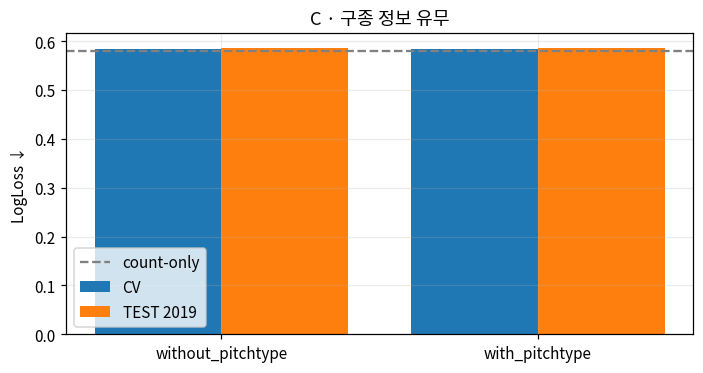

In [4]:
plt.figure(figsize=(6.5,3.5))
x = np.arange(len(comp)); plt.bar(x-0.2, comp["CV_logloss"], 0.4, label="CV")
plt.bar(x+0.2, comp["TEST_logloss"], 0.4, label="TEST 2019")
plt.axhline(BASE["count_only"]["logloss"], ls="--", c="gray", label="count-only")
plt.xticks(x, comp.index); plt.ylabel("LogLoss ↓"); plt.title("C · 구종 정보 유무"); plt.legend(); plt.tight_layout(); plt.show()